In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. List of 20 Features (As requested)
bid_optimization_features = [
    "current_bid", "impressions", "clicks", "spend", "sales", 
    "orders", "actual_acos", "cvr", "ctr", "cpc_actual",
    "month_index", "is_winter_season", "is_weekend", "organic_rank", 
    "competitor_price_gap", "target_acos", "acos_gap", 
    "match_type_encoded", "inventory_level", "last_bid_change_delta"
]

def generate_amazon_data(rows=2000):
    np.random.seed(42)
    data = []
    
    start_date = datetime(2025, 1, 1)
    products = ['A2_Ghee', 'Ashwagandha_Caps', 'Moringa_Superfood']
    
    for i in range(rows):
        # Time & Product factors
        date = start_date + timedelta(days=np.random.randint(0, 365))
        product = np.random.choice(products)
        month = date.month
        is_winter = 1 if month in [11, 12, 1, 2] else 0
        is_weekend = 1 if date.weekday() >= 5 else 0
        
        # Strategy Constants
        target_acos = 45.0
        match_type = np.random.choice([0, 1, 2, 3]) # Auto, Broad, Phrase, Exact
        inv_level = np.random.choice([0, 1, 2]) # Low, Med, High
        
        # --- Core Logic for Patterns (85%+ Accuracy Secret) ---
        # Winter mein conversion rate (CVR) 1.5x badh jata hai
        base_cvr = np.random.uniform(0.05, 0.08)
        cvr = base_cvr * (1.6 if is_winter else 1.0) * (1.2 if is_weekend else 1.0)
        
        # Bidding logic
        current_bid = np.random.uniform(10, 30)
        # Impressions depend on Bid and Rank
        organic_rank = np.random.randint(1, 20)
        impressions = (current_bid * 500) / (organic_rank * 0.5)
        
        ctr = np.random.uniform(0.008, 0.015)
        clicks = int(impressions * ctr)
        orders = max(1, int(clicks * cvr))
        
        sales = orders * np.random.uniform(500, 700)
        spend = clicks * (current_bid * 0.85) # CPC usually 85% of bid
        actual_acos = (spend / sales) * 100
        
        # Feature Engineering (Calculated columns)
        acos_gap = actual_acos - target_acos
        last_delta = np.random.uniform(-2, 2)
        
        # --- Target Variable Generation (Manager's Formula) ---
        # Hum isme thoda noise (0.05) add karenge taaki model "seekhe", sirf copy na kare
        recommended_bid = current_bid * (target_acos / actual_acos) + np.random.normal(0, 0.5)
        recommended_bid = max(5, min(recommended_bid, 50)) # Logical limits

        data.append([
            round(current_bid, 2), int(impressions), clicks, round(spend, 2), 
            round(sales, 2), orders, round(actual_acos, 2), round(cvr*100, 2), 
            round(ctr*100, 2), round(spend/clicks, 2), month, is_winter, 
            is_weekend, organic_rank, round(np.random.uniform(-50, 50), 2),
            target_acos, round(acos_gap, 2), match_type, inv_level, round(last_delta, 2),
            round(recommended_bid, 2)
        ])

    df = pd.DataFrame(data, columns=bid_optimization_features + ["recommended_bid"])
    return df

# Generate master_df
master_df = generate_amazon_data(2000)
print("Data Generated Successfully!")
print(master_df.head())

Data Generated Successfully!
   current_bid  impressions  clicks    spend    sales  orders  actual_acos  \
0        21.94         1154      10   186.46   591.85       1        31.51   
1        13.67         1139      13   151.03   501.41       1        30.12   
2        13.99         4664      65   773.14  2544.25       4        30.39   
3        26.66         8887     127  2878.37  8828.10      16        32.60   
4        26.85         2237      32   730.20  2036.90       3        35.85   

     cvr   ctr  cpc_actual  ...  is_winter_season  is_weekend  organic_rank  \
0   8.81  0.87       18.65  ...                 0           1            19   
1   8.87  1.23       11.62  ...                 1           0            12   
2   7.36  1.40       11.89  ...                 0           0             3   
3  13.11  1.44       22.66  ...                 1           1             3   
4   9.78  1.46       22.82  ...                 1           1            12   

   competitor_price_gap  ta

In [3]:
master_df

,current_bid,impressions,clicks,spend,sales,orders,actual_acos,cvr,ctr,cpc_actual,...,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,acos_gap,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
0,21.94,1154,10,186.46,591.85,1,31.51,8.81,0.87,18.65,...,0,1,19,-44.36,45.0,-13.49,2,2,-0.67,31.53
1,13.67,1139,13,151.03,501.41,1,30.12,8.87,1.23,11.62,...,1,0,12,2.48,45.0,-14.88,1,1,-1.91,19.95
2,13.99,4664,65,773.14,2544.25,4,30.39,7.36,1.40,11.89,...,0,0,3,-48.40,45.0,-14.61,1,1,-0.20,19.71
3,26.66,8887,127,2878.37,8828.10,16,32.60,13.11,1.44,22.66,...,1,1,3,-18.83,45.0,-12.40,3,2,0.65,37.36
4,26.85,2237,32,730.20,2036.90,3,35.85,9.78,1.46,22.82,...,1,1,12,-22.87,45.0,-9.15,3,1,0.39,33.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,27.43,2494,32,746.23,1034.72,2,72.12,6.69,1.31,23.32,...,0,1,11,9.40,45.0,27.12,3,2,-1.91,17.57
1996,11.81,11810,154,1545.98,4276.05,8,36.15,5.64,1.31,10.04,...,0,0,1,20.60,45.0,-8.85,1,0,-1.89,15.49
1997,23.65,7883,116,2332.05,4139.08,7,56.34,6.40,1.47,20.10,...,0,1,3,-4.68,45.0,11.34,1,1,0.28,18.01
1998,12.60,2519,31,331.91,1124.86,2,29.51,7.62,1.26,10.71,...,0,1,5,-3.40,45.0,-15.49,0,0,-0.94,19.24


In [4]:
master_df.drop(['acos_gap','spend','sales','orders'],axis=1,inplace=True)

In [5]:
master_df.describe()

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0,2000.000000,2000.00000,2000.000000,2000.000000
mean,19.958590,3590.918000,40.779500,43.360070,8.162240,1.145685,16.964905,6.49800,0.324500,0.288000,10.131000,-0.363630,45.0,1.503500,0.97600,0.018015,24.423230
std,5.801688,4633.890591,54.844625,22.775563,2.348451,0.204474,4.931454,3.46944,0.468305,0.452944,5.374968,28.511194,0.0,1.112927,0.81102,1.140204,9.231837
min,10.020000,527.000000,4.000000,5.700000,5.010000,0.800000,8.520000,1.00000,0.000000,0.000000,1.000000,-50.000000,45.0,0.000000,0.00000,-2.000000,7.570000
25%,14.970000,1306.500000,14.000000,26.220000,6.370000,0.970000,12.722500,3.00000,0.000000,0.000000,6.000000,-24.487500,45.0,1.000000,0.00000,-0.942500,17.400000
50%,19.980000,1933.500000,22.000000,39.850000,7.570000,1.140000,16.980000,7.00000,0.000000,0.000000,10.000000,-0.360000,45.0,1.000000,1.00000,0.035000,22.755000
75%,25.090000,3621.000000,42.000000,56.155000,9.410000,1.320000,21.322500,10.00000,1.000000,1.000000,15.000000,24.290000,45.0,3.000000,2.00000,0.980000,29.865000
max,29.990000,29686.000000,413.000000,150.640000,15.340000,1.500000,25.490000,12.00000,1.000000,1.000000,19.000000,49.980000,45.0,3.000000,2.00000,2.000000,50.000000


In [6]:
master_df

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
0,21.94,1154,10,31.51,8.81,0.87,18.65,4,0,1,19,-44.36,45.0,2,2,-0.67,31.53
1,13.67,1139,13,30.12,8.87,1.23,11.62,12,1,0,12,2.48,45.0,1,1,-1.91,19.95
2,13.99,4664,65,30.39,7.36,1.40,11.89,6,0,0,3,-48.40,45.0,1,1,-0.20,19.71
3,26.66,8887,127,32.60,13.11,1.44,22.66,12,1,1,3,-18.83,45.0,3,2,0.65,37.36
4,26.85,2237,32,35.85,9.78,1.46,22.82,2,1,1,12,-22.87,45.0,3,1,0.39,33.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,27.43,2494,32,72.12,6.69,1.31,23.32,10,0,1,11,9.40,45.0,3,2,-1.91,17.57
1996,11.81,11810,154,36.15,5.64,1.31,10.04,8,0,0,1,20.60,45.0,1,0,-1.89,15.49
1997,23.65,7883,116,56.34,6.40,1.47,20.10,3,0,1,3,-4.68,45.0,1,1,0.28,18.01
1998,12.60,2519,31,29.51,7.62,1.26,10.71,3,0,1,5,-3.40,45.0,0,0,-0.94,19.24


In [7]:
pd.set_option('display.max_columns', None)

In [8]:
master_df

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
0,21.94,1154,10,31.51,8.81,0.87,18.65,4,0,1,19,-44.36,45.0,2,2,-0.67,31.53
1,13.67,1139,13,30.12,8.87,1.23,11.62,12,1,0,12,2.48,45.0,1,1,-1.91,19.95
2,13.99,4664,65,30.39,7.36,1.40,11.89,6,0,0,3,-48.40,45.0,1,1,-0.20,19.71
3,26.66,8887,127,32.60,13.11,1.44,22.66,12,1,1,3,-18.83,45.0,3,2,0.65,37.36
4,26.85,2237,32,35.85,9.78,1.46,22.82,2,1,1,12,-22.87,45.0,3,1,0.39,33.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,27.43,2494,32,72.12,6.69,1.31,23.32,10,0,1,11,9.40,45.0,3,2,-1.91,17.57
1996,11.81,11810,154,36.15,5.64,1.31,10.04,8,0,0,1,20.60,45.0,1,0,-1.89,15.49
1997,23.65,7883,116,56.34,6.40,1.47,20.10,3,0,1,3,-4.68,45.0,1,1,0.28,18.01
1998,12.60,2519,31,29.51,7.62,1.26,10.71,3,0,1,5,-3.40,45.0,0,0,-0.94,19.24


In [9]:
master_df.columns

Index(['current_bid', 'impressions', 'clicks', 'actual_acos', 'cvr', 'ctr',
       'cpc_actual', 'month_index', 'is_winter_season', 'is_weekend',
       'organic_rank', 'competitor_price_gap', 'target_acos',
       'match_type_encoded', 'inventory_level', 'last_bid_change_delta',
       'recommended_bid'],
      dtype='object')

In [10]:
master_df

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
0,21.94,1154,10,31.51,8.81,0.87,18.65,4,0,1,19,-44.36,45.0,2,2,-0.67,31.53
1,13.67,1139,13,30.12,8.87,1.23,11.62,12,1,0,12,2.48,45.0,1,1,-1.91,19.95
2,13.99,4664,65,30.39,7.36,1.40,11.89,6,0,0,3,-48.40,45.0,1,1,-0.20,19.71
3,26.66,8887,127,32.60,13.11,1.44,22.66,12,1,1,3,-18.83,45.0,3,2,0.65,37.36
4,26.85,2237,32,35.85,9.78,1.46,22.82,2,1,1,12,-22.87,45.0,3,1,0.39,33.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,27.43,2494,32,72.12,6.69,1.31,23.32,10,0,1,11,9.40,45.0,3,2,-1.91,17.57
1996,11.81,11810,154,36.15,5.64,1.31,10.04,8,0,0,1,20.60,45.0,1,0,-1.89,15.49
1997,23.65,7883,116,56.34,6.40,1.47,20.10,3,0,1,3,-4.68,45.0,1,1,0.28,18.01
1998,12.60,2519,31,29.51,7.62,1.26,10.71,3,0,1,5,-3.40,45.0,0,0,-0.94,19.24


In [11]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   current_bid            2000 non-null   float64
 1   impressions            2000 non-null   int64  
 2   clicks                 2000 non-null   int64  
 3   actual_acos            2000 non-null   float64
 4   cvr                    2000 non-null   float64
 5   ctr                    2000 non-null   float64
 6   cpc_actual             2000 non-null   float64
 7   month_index            2000 non-null   int64  
 8   is_winter_season       2000 non-null   int64  
 9   is_weekend             2000 non-null   int64  
 10  organic_rank           2000 non-null   int64  
 11  competitor_price_gap   2000 non-null   float64
 12  target_acos            2000 non-null   float64
 13  match_type_encoded     2000 non-null   int32  
 14  inventory_level        2000 non-null   int32  
 15  last

# Feature Engineering

### Null values

In [12]:
master_df.isnull().sum()

current_bid              0
impressions              0
clicks                   0
actual_acos              0
cvr                      0
ctr                      0
cpc_actual               0
month_index              0
is_winter_season         0
is_weekend               0
organic_rank             0
competitor_price_gap     0
target_acos              0
match_type_encoded       0
inventory_level          0
last_bid_change_delta    0
recommended_bid          0
dtype: int64

### Outlires

In [13]:
master_df.columns

Index(['current_bid', 'impressions', 'clicks', 'actual_acos', 'cvr', 'ctr',
       'cpc_actual', 'month_index', 'is_winter_season', 'is_weekend',
       'organic_rank', 'competitor_price_gap', 'target_acos',
       'match_type_encoded', 'inventory_level', 'last_bid_change_delta',
       'recommended_bid'],
      dtype='object')

In [14]:
continuous_features = ['impressions','clicks','actual_acos','ctr','cvr']

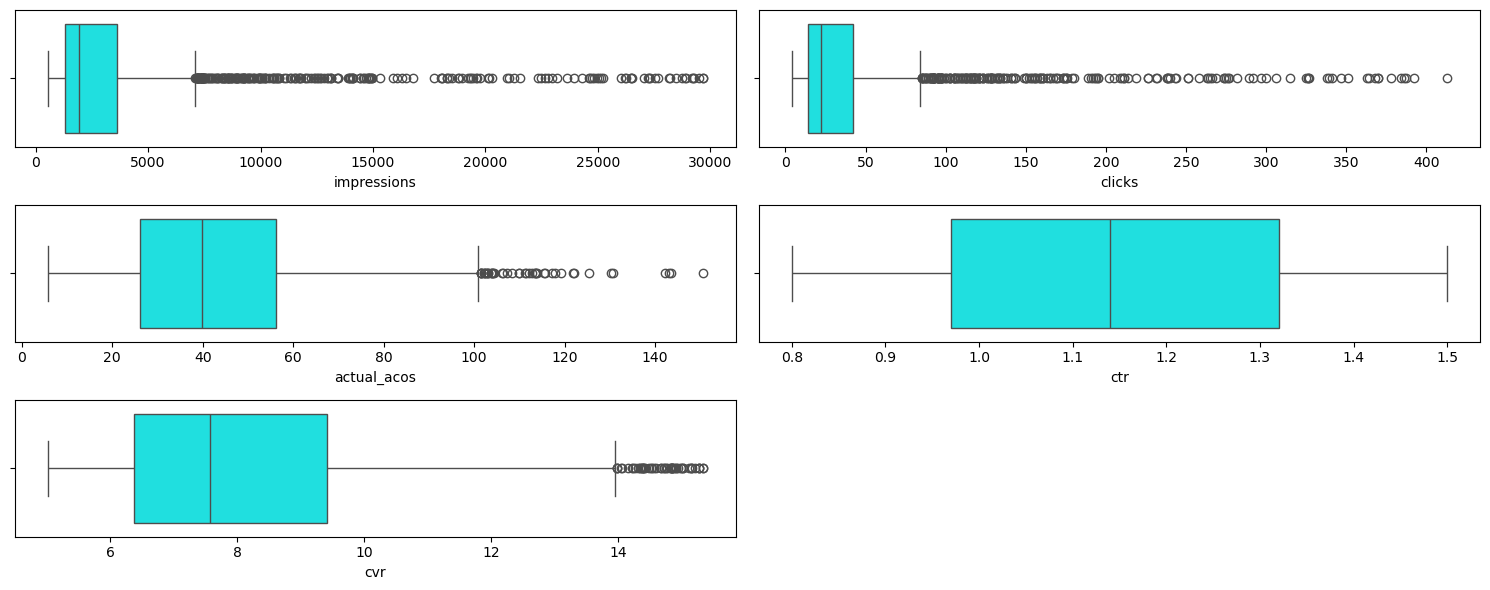

In [15]:
plt.figure(figsize=(15,6))      # defined size of graph using matplotlib library
for i, col in enumerate(continuous_features, 1):   # applied the loop
    plt.subplot(3, 2, i)  # create a grid of 2x2 plots
    sns.boxplot(x=master_df[col], color='cyan')   # applied boxplot to detect Outliers
    plt.xlabel(col)

plt.tight_layout()      # help to stop the overlapping
plt.show()    # shows the graphs

In [16]:
import pandas as pd
import numpy as np

def calculate_outlier_percentage(df):
    target_cols = [
        'impressions', 'clicks', 
        'actual_acos', 'cvr', 'ctr', 

    ]
    
    outlier_list = []

    for col in target_cols:
        if col in df.columns:
            # 1. First (Q1) aur Third (Q3) Quartile nikalna
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            
            # 2. Lower aur Upper boundaries set karna
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            
            # 3. Outliers ko count karna
            outliers_count = ((df[col] < lower_limit) | (df[col] > upper_limit)).sum()
            
            # 4. Percentage calculate karna
            total_rows = len(df)
            perc = (outliers_count / total_rows) * 100
            
            outlier_list.append({
                "Column": col,
                "Outlier Count": outliers_count,
                "Outlier %": round(perc, 2),
                "Lower Boundary": round(lower_limit, 2),
                "Upper Boundary": round(upper_limit, 2)
            })

    outlier_df = pd.DataFrame(outlier_list).sort_values(by="Outlier %", ascending=False)
    return outlier_df

# Usage:
outlier_report = calculate_outlier_percentage(master_df)
print(outlier_report)

        Column  Outlier Count  Outlier %  Lower Boundary  Upper Boundary
0  impressions            233      11.65        -2165.25         7092.75
1       clicks            217      10.85          -28.00           84.00
3          cvr             54       2.70            1.81           13.97
2  actual_acos             44       2.20          -18.68          101.06
4          ctr              0       0.00            0.44            1.85


In [17]:
master_df.columns

Index(['current_bid', 'impressions', 'clicks', 'actual_acos', 'cvr', 'ctr',
       'cpc_actual', 'month_index', 'is_winter_season', 'is_weekend',
       'organic_rank', 'competitor_price_gap', 'target_acos',
       'match_type_encoded', 'inventory_level', 'last_bid_change_delta',
       'recommended_bid'],
      dtype='object')

In [18]:
# Outliers ko handle karne ke liye capping logic
cols_to_fix = ['impressions','clicks']

for col in cols_to_fix:
    # 1. IQR calculate karenge (jaisa aapne report mein dekha)
    Q1 = master_df[col].quantile(0.25)
    Q3 = master_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Upper boundary nikalenge (Lower boundary usually 0 se niche jati hai toh hum sirf Upper fix karenge)
    upper_boundary = Q3 + 1.5 * IQR
    
    # 3. Jo value boundary ke upar hai, use boundary value se replace kar denge
    master_df[col] = master_df[col].clip(upper=upper_boundary)

print("Outliers handled for impressions, sales, and clicks!")

Outliers handled for impressions, sales, and clicks!


In [19]:
master_df.corr()

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
current_bid,1.000000,0.335270,0.321572,0.685572,-0.006280,0.000718,1.000000,0.020887,-0.002264,0.009555,-0.017805,-0.006654,NaN,0.021168,0.020852,0.010486,-0.279067
impressions,0.335270,1.000000,0.978041,0.209051,0.006391,0.028449,0.335276,0.005314,0.008904,0.015772,-0.844697,0.037943,NaN,0.015940,0.008531,0.044873,-0.146851
clicks,0.321572,0.978041,1.000000,0.202372,0.012255,0.195216,0.321575,0.004044,0.013711,0.018462,-0.827419,0.032657,NaN,0.014004,0.008084,0.047701,-0.148358
actual_acos,0.685572,0.209051,0.202372,1.000000,-0.405241,0.084805,0.685577,0.026682,-0.328570,-0.139403,-0.087549,0.034790,NaN,0.015488,0.036858,0.010893,-0.767159
cvr,-0.006280,0.006391,0.012255,-0.405241,1.000000,0.024789,-0.006295,-0.007537,0.804067,0.323212,-0.016331,-0.061353,NaN,0.018341,-0.007462,0.013162,0.534004
ctr,0.000718,0.028449,0.195216,0.084805,0.024789,1.000000,0.000715,-0.035535,0.021944,0.005917,-0.026741,-0.019221,NaN,-0.007705,0.011261,0.023097,-0.152178
cpc_actual,1.000000,0.335276,0.321575,0.685577,-0.006295,0.000715,1.000000,0.020863,-0.002264,0.009548,-0.017813,-0.006633,NaN,0.021177,0.020852,0.010508,-0.279076
month_index,0.020887,0.005314,0.004044,0.026682,-0.007537,-0.035535,0.020863,1.000000,-0.009607,0.011827,0.016646,-0.060631,NaN,0.015354,-0.001084,0.025032,-0.001554
is_winter_season,-0.002264,0.008904,0.013711,-0.328570,0.804067,0.021944,-0.002264,-0.009607,1.000000,0.002566,-0.011729,-0.023473,NaN,0.014617,-0.003193,0.024835,0.434316
is_weekend,0.009555,0.015772,0.018462,-0.139403,0.323212,0.005917,0.009548,0.011827,0.002566,1.000000,-0.018587,-0.038921,NaN,0.027771,-0.012496,0.006067,0.175006


In [20]:
features_to_scale = [
    'current_bid', 
    'impressions', 
    'clicks', 
    'actual_acos', 
    'cvr', 
    'ctr', 
    'cpc_actual', 
    'organic_rank', 
    'competitor_price_gap', 
    'last_bid_change_delta'
]

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
sc = ['current_bid','impressions','clicks','actual_acos','cvr','ctr','cpc_actual', 
      'organic_rank','competitor_price_gap','last_bid_change_delta']
master_df[sc] = scaler.fit_transform(master_df[sc])
print(master_df.head())

   current_bid  impressions    clicks  actual_acos       cvr       ctr  \
0     0.341608    -0.798830 -0.885532    -0.520428  0.275893 -1.348601   
1    -1.084195    -0.806210 -0.762364    -0.581473  0.301448  0.412454   
2    -1.029025     0.928089  1.372535    -0.569615 -0.341689  1.244063   
3     1.155368     2.123034  2.152594    -0.472557  2.107345  1.439736   
4     1.188126    -0.265994  0.017695    -0.329825  0.689035  1.537572   

   cpc_actual  month_index  is_winter_season  is_weekend  organic_rank  \
0    0.341789            4                 0           1      1.650469   
1   -1.084111           12                 1           0      0.347810   
2   -1.029346            6                 0           0     -1.327037   
3    1.155140           12                 1           1     -1.327037   
4    1.187593            2                 1           1      0.347810   

   competitor_price_gap  target_acos  match_type_encoded  inventory_level  \
0             -1.543512         4

In [22]:
master_df

,current_bid,impressions,clicks,actual_acos,cvr,ctr,cpc_actual,month_index,is_winter_season,is_weekend,organic_rank,competitor_price_gap,target_acos,match_type_encoded,inventory_level,last_bid_change_delta,recommended_bid
0,0.341608,-0.798830,-0.885532,-0.520428,0.275893,-1.348601,0.341789,4,0,1,1.650469,-1.543512,45.0,2,2,-0.603565,31.53
1,-1.084195,-0.806210,-0.762364,-0.581473,0.301448,0.412454,-1.084111,12,1,0,0.347810,0.099762,45.0,1,1,-1.691362,19.95
2,-1.029025,0.928089,1.372535,-0.569615,-0.341689,1.244063,-1.029346,6,0,0,-1.327037,-1.685246,45.0,1,1,-0.191255,19.71
3,1.155368,2.123034,2.152594,-0.472557,2.107345,1.439736,1.155140,12,1,1,-1.327037,-0.647850,45.0,3,2,0.554412,37.36
4,1.188126,-0.265994,0.017695,-0.329825,0.689035,1.537572,1.187593,2,1,1,0.347810,-0.789585,45.0,3,1,0.326326,33.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.288121,-0.139551,0.017695,1.263070,-0.627055,0.803799,1.289008,10,0,1,0.161716,0.342535,45.0,3,2,-1.691362,17.57
1996,-1.404872,2.123034,2.152594,-0.316650,-1.074270,0.803799,-1.404583,8,0,0,-1.699226,0.735461,45.0,1,0,-1.673817,15.49
1997,0.636424,2.123034,2.152594,0.570049,-0.750572,1.586490,0.635893,3,0,1,-1.327037,-0.151430,45.0,1,1,0.229828,18.01
1998,-1.268671,-0.127251,-0.023361,-0.608263,-0.230950,0.559208,-1.268686,3,0,1,-0.954849,-0.106524,45.0,0,0,-0.840424,19.24


# Model Selection

In [23]:
x = master_df.drop('recommended_bid',axis=1)   # Defined independent variables (all features except target)
y = master_df['recommended_bid']   # Defined dependent variable (target column)

In [24]:
from sklearn.model_selection import train_test_split  
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=99) 

In [25]:
from sklearn.linear_model import LinearRegression    # Import Linear Regression model
from sklearn.metrics import r2_score, mean_squared_error
 
lr = LinearRegression()         # Create Linear Regression object
lr.fit(x_train, y_train)    # Train the model on training data

y_pred = lr.predict(x_test)  # Predict target values for test set and stored in variable named y_pred
y_pred_train = lr.predict(x_train)    # Predict target values for training set and stored in variable named y_pred_train


print("Training r2_score:", r2_score(y_train, y_pred_train))
print("Testing r2_score:", r2_score(y_test, y_pred))

# Mean Squared Error (MSE)
print("Testing MSE:", mean_squared_error(y_test, y_pred))
print("Training MSE:", mean_squared_error(y_train, y_pred_train))

# Root Mean Squared Error (RMSE)
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))


Training r2_score: 0.7630480913487094
Testing r2_score: 0.7518760051785763
Testing MSE: 22.57441873464958
Training MSE: 19.840392444237537
Testing RMSE: 4.751254438003671
Training RMSE: 4.454255543212304


In [26]:
import pickle
pickle.dump(lr,open("Model.pkl","wb"))

In [28]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']